# FreshCart India — Marketing Campaign Performance Analysis
**Author:** Siddula Ajay Chand | Data Analyst, Citta AI  
**Client:** FreshCart India (E-commerce Grocery & Household)  
**Period:** October 2024 – March 2026 (18 months)  
**Channels:** Meta · Google · LinkedIn · YouTube  
**Markets:** South · West · North · East India  

---
## Pipeline
```
Raw Excel (messy) → MySQL Cleaning → Python EDA → Power BI Dashboard
```

## Notebook Sections
1. Setup & Config
2. Load & Validate Clean Data
3. Overall KPI Summary
4. Channel Performance Analysis
5. Monthly & Quarterly Trends
6. Regional & City Analysis
7. Product Category Performance
8. Device & Placement Analysis
9. Audience Demographics
10. Key Insights & Recommendations
11. Export Summary CSVs for Power BI

## 1. Setup & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── SET YOUR OUTPUT FOLDER PATH ──────────────────────────────
# This folder must contain your 3 exported MySQL CSVs
# Change this path to match YOUR system
OUTPUT = r'C:\Users\Vijay\OneDrive\Desktop\Python\grocery-campaign-analysis\output'
os.makedirs(OUTPUT, exist_ok=True)

# ── PLOT STYLE ───────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── COLOUR MAPS ──────────────────────────────────────────────
CHANNEL_COLORS = {
    'Meta':     '#1877F2',
    'Google':   '#EA4335',
    'Linkedin': '#0A66C2',
    'Youtube':  '#FF0000',
}
REGION_COLORS = {
    'South': '#138808',
    'West':  '#9B59B6',
    'North': '#FF9933',
    'East':  '#1A3C5E',
}

print('✅ Setup complete')
print(f'   Output folder: {OUTPUT}')

✅ Setup complete
   Output folder: C:\Users\Vijay\OneDrive\Desktop\Python\grocery-campaign-analysis\output


## 2. Load & Validate Clean Data

In [2]:
# ── LOAD 3 CLEAN CSVs FROM MySQL OUTPUT ──────────────────────
# MySQL Workbench exports with comma separator by default
# If your spend_clean.csv opens with wrong columns, it may be
# semicolon-separated — the auto-detect below handles both cases

def load_csv_auto(path, **kwargs):
    """Auto-detect CSV separator (comma or semicolon)"""
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        first_line = f.readline()
    sep = ';' if first_line.count(';') > first_line.count(',') else ','
    return pd.read_csv(path, sep=sep, **kwargs)

df = load_csv_auto(os.path.join(OUTPUT, 'campaign_clean.csv'),  parse_dates=['date'])
sp = load_csv_auto(os.path.join(OUTPUT, 'spend_clean.csv'),     parse_dates=['date'])
au = load_csv_auto(os.path.join(OUTPUT, 'audience_clean.csv'),  parse_dates=['week_starting'])

# ── NORMALISE COLUMN TYPES ───────────────────────────────────
# MySQL export can leave numeric columns as strings — coerce all
for col in ['spend_inr','revenue_inr','impressions','clicks','conversions',
            'ctr_pct','cvr_pct','cpc_inr','roi_pct','roas','cac_inr']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['spend_inr','impressions','clicks','cpc_inr']:
    if col in sp.columns:
        sp[col] = pd.to_numeric(sp[col], errors='coerce')

for col in ['spend_inr','revenue_inr','impressions','clicks','conversions']:
    if col in au.columns:
        au[col] = pd.to_numeric(au[col], errors='coerce')

# ── NORMALISE CHANNEL/DEVICE CASING (safety net) ─────────────
# In case MySQL export preserved raw casing
for col in ['channel']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: str(x)[0].upper()+str(x)[1:].lower() if pd.notna(x) and str(x) else x)
    if col in sp.columns:
        sp[col] = sp[col].apply(lambda x: str(x)[0].upper()+str(x)[1:].lower() if pd.notna(x) and str(x) else x)
    if col in au.columns:
        au[col] = au[col].apply(lambda x: str(x)[0].upper()+str(x)[1:].lower() if pd.notna(x) and str(x) else x)

if 'device' in sp.columns:
    sp['device'] = sp['device'].apply(lambda x: str(x)[0].upper()+str(x)[1:].lower() if pd.notna(x) and str(x) else x)

# ── TIME COLUMNS (in case not exported from MySQL) ───────────
if 'month'   not in df.columns: df['month']   = df['date'].dt.to_period('M').astype(str)
if 'quarter' not in df.columns: df['quarter'] = df['date'].dt.to_period('Q').astype(str)
if 'year'    not in df.columns: df['year']    = df['date'].dt.year

# ── VALIDATION REPORT ────────────────────────────────────────
print('=' * 60)
print('DATA LOAD SUMMARY')
print('=' * 60)
print(f'Campaign records   : {len(df):,}')
print(f'Spend records      : {len(sp):,}')
print(f'Audience records   : {len(au):,}')
print(f'Date range         : {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Channels (campaign): {sorted(df["channel"].dropna().unique())}')
print(f'Channels (spend)   : {sorted(sp["channel"].dropna().unique())}')
print(f'Regions            : {sorted(df["region"].dropna().unique())}')
print(f'Cities             : {df["city"].nunique()} unique')
print(f'Campaigns          : {df["campaign_name"].nunique()} unique')
print(f'Product categories : {df["product_category"].nunique()} unique')
print()
print('Null check (should all be 0):')
print(df[['spend_inr','revenue_inr','clicks','impressions','conversions']].isnull().sum())
df.head(3)

DATA LOAD SUMMARY
Campaign records   : 8,552
Spend records      : 13,018
Audience records   : 4,588
Date range         : 2024-10-01 to 2026-03-31
Channels (campaign): ['Google', 'Linkedin', 'Meta', 'Youtube']
Channels (spend)   : ['Google', 'Linkedin', 'Meta', 'Youtube']
Regions            : ['East', 'North', 'South', 'West']
Cities             : 21 unique
Campaigns          : 38 unique
Product categories : 9 unique

Null check (should all be 0):
spend_inr      0
revenue_inr    0
clicks         0
impressions    0
conversions    0
dtype: int64


,date,channel,campaign_name,product_category,region,city,spend_inr,impressions,clicks,conversions,...,cvr_pct,cpc_inr,roi_pct,roas,cac_inr,month,quarter,year,week_num,campaign_id
0,2025-01-01,Google,Performance Max - All Products,Packaged Foods,East,Kolkata,9071.36,6431,309,8,...,2.5890,29.36,243.98,3.4398,1133.92,2025-01,2025-Q1,2025,1,FC-GO-9239
1,2025-01-01,Google,Search - Grocery Delivery,Fruits,South,Chennai,7827.06,12263,870,44,...,5.0575,9.00,486.53,5.8653,177.89,2025-01,2025-Q1,2025,1,FC-GO-7566
2,2025-01-01,Google,Search - Household Items,Organic & Natural,North,Jaipur,12340.12,6260,355,17,...,4.7887,34.76,407.79,5.0779,725.89,2025-01,2025-Q1,2025,1,FC-GO-7804


## 3. Overall KPI Summary

In [3]:
total_spend   = df['spend_inr'].sum()
total_revenue = df['revenue_inr'].sum()
total_conv    = df['conversions'].sum()
total_clicks  = df['clicks'].sum()
total_imp     = df['impressions'].sum()

roi  = (total_revenue - total_spend) / total_spend * 100
roas = total_revenue / total_spend
ctr  = total_clicks  / total_imp    * 100
cvr  = total_conv    / total_clicks * 100
cac  = total_spend   / total_conv

print('=' * 60)
print('OVERALL KPIs — Oct 2024 to Mar 2026')
print('=' * 60)
kpi_data = [
    ('Total Spend',       f'Rs.{total_spend/100000:.1f} Lakhs'),
    ('Total Revenue',     f'Rs.{total_revenue/100000:.1f} Lakhs'),
    ('Total Conversions', f'{total_conv:,.0f}'),
    ('Overall ROI',       f'{roi:.1f}%'),
    ('Overall ROAS',      f'{roas:.2f}x'),
    ('Overall CTR',       f'{ctr:.2f}%'),
    ('Overall CVR',       f'{cvr:.2f}%'),
    ('Overall CAC',       f'Rs.{cac:.0f}'),
]
for label, val in kpi_data:
    print(f'  {label:<22}: {val}')

OVERALL KPIs — Oct 2024 to Mar 2026
  Total Spend           : Rs.604.5 Lakhs
  Total Revenue         : Rs.1786.9 Lakhs
  Total Conversions     : 66,003
  Overall ROI           : 195.6%
  Overall ROAS          : 2.96x
  Overall CTR           : 1.75%
  Overall CVR           : 2.42%
  Overall CAC           : Rs.916


## 4. Channel Performance Analysis

In [4]:
ch = df.groupby('channel').agg(
    spend       = ('spend_inr',   'sum'),
    revenue     = ('revenue_inr', 'sum'),
    conversions = ('conversions', 'sum'),
    clicks      = ('clicks',      'sum'),
    impressions = ('impressions', 'sum'),
).reset_index()

ch['roi_pct']     = ((ch['revenue'] - ch['spend']) / ch['spend'] * 100).round(1)
ch['roas']        = (ch['revenue'] / ch['spend']).round(2)
ch['cac']         = (ch['spend'] / ch['conversions'].replace(0, np.nan)).round(0)
ch['ctr_pct']     = (ch['clicks'] / ch['impressions'] * 100).round(2)
ch['cvr_pct']     = (ch['conversions'] / ch['clicks'].replace(0, np.nan) * 100).round(2)
ch['spend_share'] = (ch['spend'] / ch['spend'].sum() * 100).round(1)
ch['spend_L']     = (ch['spend']   / 100000).round(1)
ch['revenue_L']   = (ch['revenue'] / 100000).round(1)

print('Channel Performance Table:')
print(ch[['channel','spend_L','revenue_L','roi_pct','roas','cac','ctr_pct','cvr_pct','spend_share']].to_string(index=False))

Channel Performance Table:
 channel  spend_L  revenue_L  roi_pct  roas    cac  ctr_pct  cvr_pct  spend_share
  Google    190.7      831.1    335.9  4.36  512.0     5.31     3.83         31.5
Linkedin     93.9      227.9    142.7  2.43 9011.0     0.69     1.03         15.5
    Meta    147.5      441.1    199.1  2.99  582.0     2.54     2.09         24.4
 Youtube    172.4      286.8     66.4  1.66 7232.0     0.59     0.54         28.5


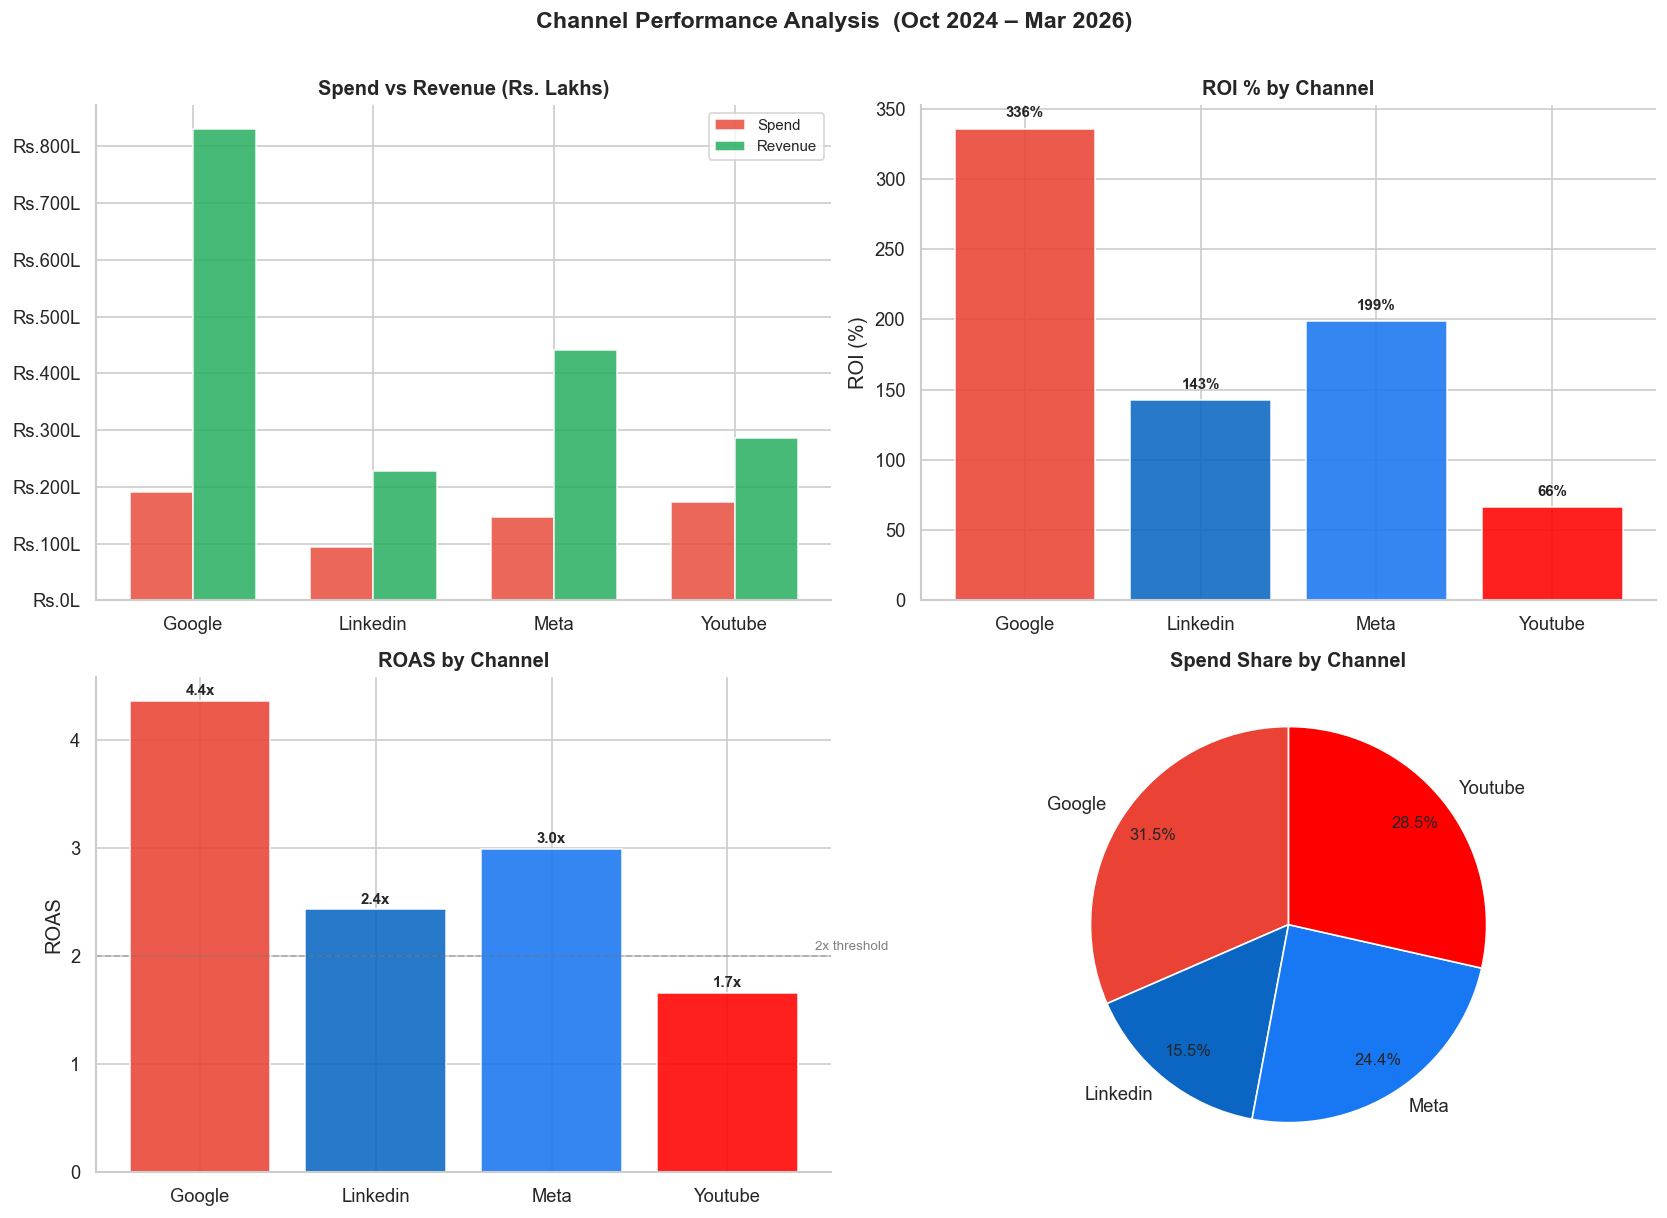

✅ Saved: channel_analysis.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Channel Performance Analysis  (Oct 2024 – Mar 2026)', fontsize=14, fontweight='bold', y=1.01)
colors = [CHANNEL_COLORS.get(c, '#888') for c in ch['channel']]

# Spend vs Revenue
ax = axes[0,0]
x, w = np.arange(len(ch)), 0.35
ax.bar(x-w/2, ch['spend_L'],   w, label='Spend',   color='#E74C3C', alpha=0.85)
ax.bar(x+w/2, ch['revenue_L'], w, label='Revenue', color='#27AE60', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(ch['channel'])
ax.set_title('Spend vs Revenue (Rs. Lakhs)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v,_: f'Rs.{v:.0f}L'))
ax.legend(fontsize=9)

# ROI %
ax = axes[0,1]
bars = ax.bar(ch['channel'], ch['roi_pct'], color=colors, alpha=0.88, edgecolor='white')
for bar, val in zip(bars, ch['roi_pct']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+8,
            f'{val:.0f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_title('ROI % by Channel'); ax.set_ylabel('ROI (%)')

# ROAS
ax = axes[1,0]
bars = ax.bar(ch['channel'], ch['roas'], color=colors, alpha=0.88, edgecolor='white')
for bar, val in zip(bars, ch['roas']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')
ax.set_title('ROAS by Channel'); ax.set_ylabel('ROAS')
ax.axhline(y=2.0, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.text(3.5, 2.05, '2x threshold', fontsize=8, color='grey')

# Spend Share Pie
ax = axes[1,1]
ax.pie(ch['spend_share'], labels=ch['channel'], autopct='%1.1f%%',
       colors=colors, startangle=90, pctdistance=0.82)
ax.set_title('Spend Share by Channel')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'channel_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: channel_analysis.png')

## 5. Monthly & Quarterly Trends

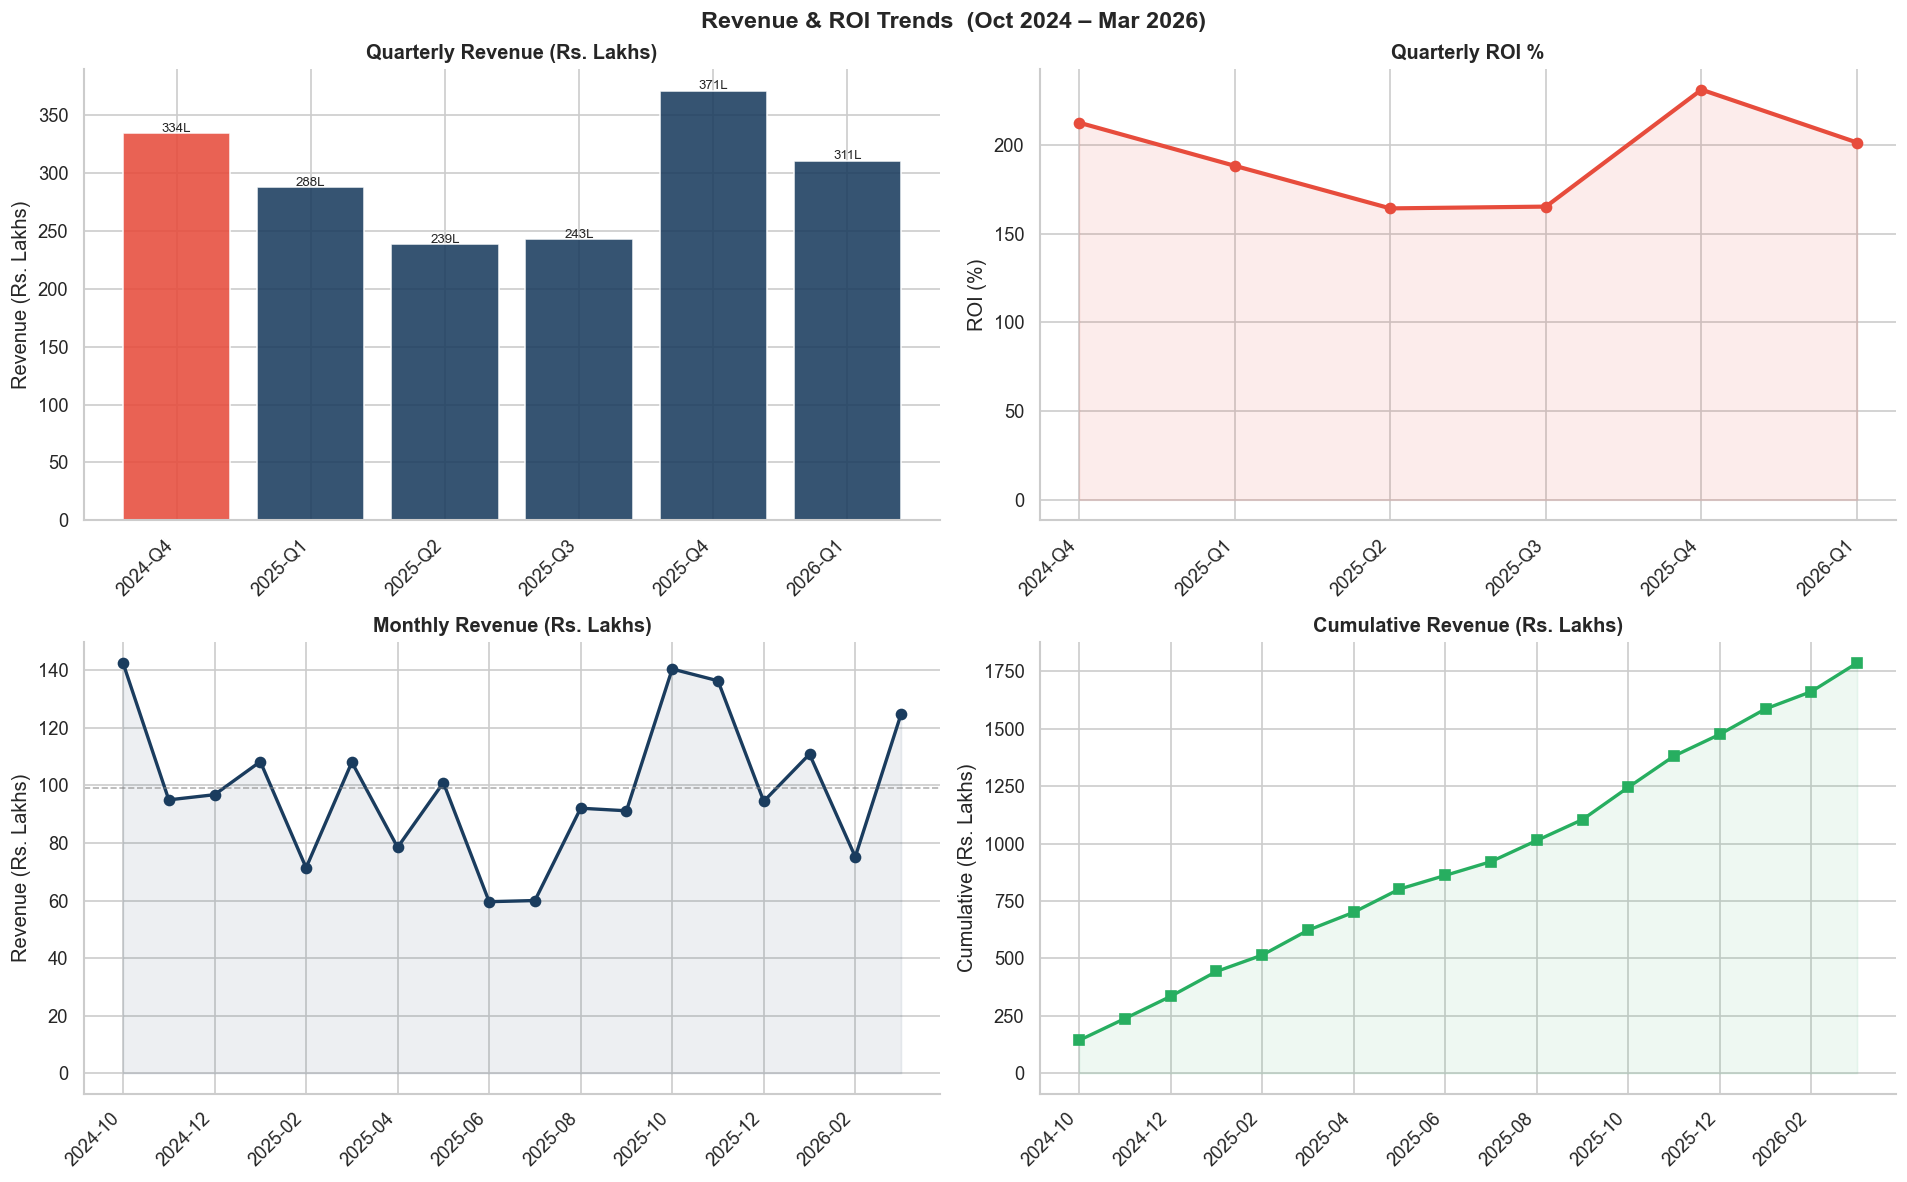

✅ Saved: trend_analysis.png


In [6]:
qtr = df.groupby('quarter').agg(
    spend=('spend_inr','sum'), revenue=('revenue_inr','sum'), conversions=('conversions','sum')
).reset_index()
qtr['roi_pct'] = ((qtr['revenue']-qtr['spend'])/qtr['spend']*100).round(1)
qtr['rev_L']   = (qtr['revenue']/100000).round(1)
qtr['spend_L'] = (qtr['spend']/100000).round(1)

mon = df.groupby('month').agg(
    spend=('spend_inr','sum'), revenue=('revenue_inr','sum'), conversions=('conversions','sum')
).reset_index()
mon['roi_pct']    = ((mon['revenue']-mon['spend'])/mon['spend']*100).round(1)
mon['roas']       = (mon['revenue']/mon['spend']).round(2)
mon['rev_L']      = (mon['revenue']/100000).round(1)
mon['spend_L']    = (mon['spend']/100000).round(1)
mon['cum_rev_L']  = mon['rev_L'].cumsum().round(1)
mon['mom_growth'] = (mon['revenue'].pct_change()*100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Revenue & ROI Trends  (Oct 2024 – Mar 2026)', fontsize=14, fontweight='bold')

# Quarterly Revenue
bar_colors = ['#E74C3C' if '2024' in q else '#1A3C5E' for q in qtr['quarter']]
axes[0,0].bar(range(len(qtr)), qtr['rev_L'], color=bar_colors, alpha=0.88)
axes[0,0].set_xticks(range(len(qtr)))
axes[0,0].set_xticklabels(qtr['quarter'], rotation=45, ha='right')
axes[0,0].set_title('Quarterly Revenue (Rs. Lakhs)')
axes[0,0].set_ylabel('Revenue (Rs. Lakhs)')
for i, v in enumerate(qtr['rev_L']):
    axes[0,0].text(i, v+1, f'{v:.0f}L', ha='center', fontsize=8)

# Quarterly ROI
axes[0,1].plot(range(len(qtr)), qtr['roi_pct'], marker='o', color='#E74C3C', linewidth=2.5)
axes[0,1].fill_between(range(len(qtr)), qtr['roi_pct'], alpha=0.1, color='#E74C3C')
axes[0,1].set_xticks(range(len(qtr)))
axes[0,1].set_xticklabels(qtr['quarter'], rotation=45, ha='right')
axes[0,1].set_title('Quarterly ROI %'); axes[0,1].set_ylabel('ROI (%)')

# Monthly Revenue
axes[1,0].plot(range(len(mon)), mon['rev_L'], marker='o', color='#1A3C5E', linewidth=2)
axes[1,0].fill_between(range(len(mon)), mon['rev_L'], alpha=0.08, color='#1A3C5E')
axes[1,0].axhline(y=mon['rev_L'].mean(), color='grey', linestyle='--', alpha=0.6, linewidth=1)
axes[1,0].set_xticks(range(0, len(mon), 2))
axes[1,0].set_xticklabels(mon['month'].iloc[::2], rotation=45, ha='right')
axes[1,0].set_title('Monthly Revenue (Rs. Lakhs)'); axes[1,0].set_ylabel('Revenue (Rs. Lakhs)')

# Cumulative Revenue
axes[1,1].plot(range(len(mon)), mon['cum_rev_L'], marker='s', color='#27AE60', linewidth=2)
axes[1,1].fill_between(range(len(mon)), mon['cum_rev_L'], alpha=0.08, color='#27AE60')
axes[1,1].set_xticks(range(0, len(mon), 2))
axes[1,1].set_xticklabels(mon['month'].iloc[::2], rotation=45, ha='right')
axes[1,1].set_title('Cumulative Revenue (Rs. Lakhs)'); axes[1,1].set_ylabel('Cumulative (Rs. Lakhs)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'trend_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: trend_analysis.png')

## 6. Regional & City Analysis

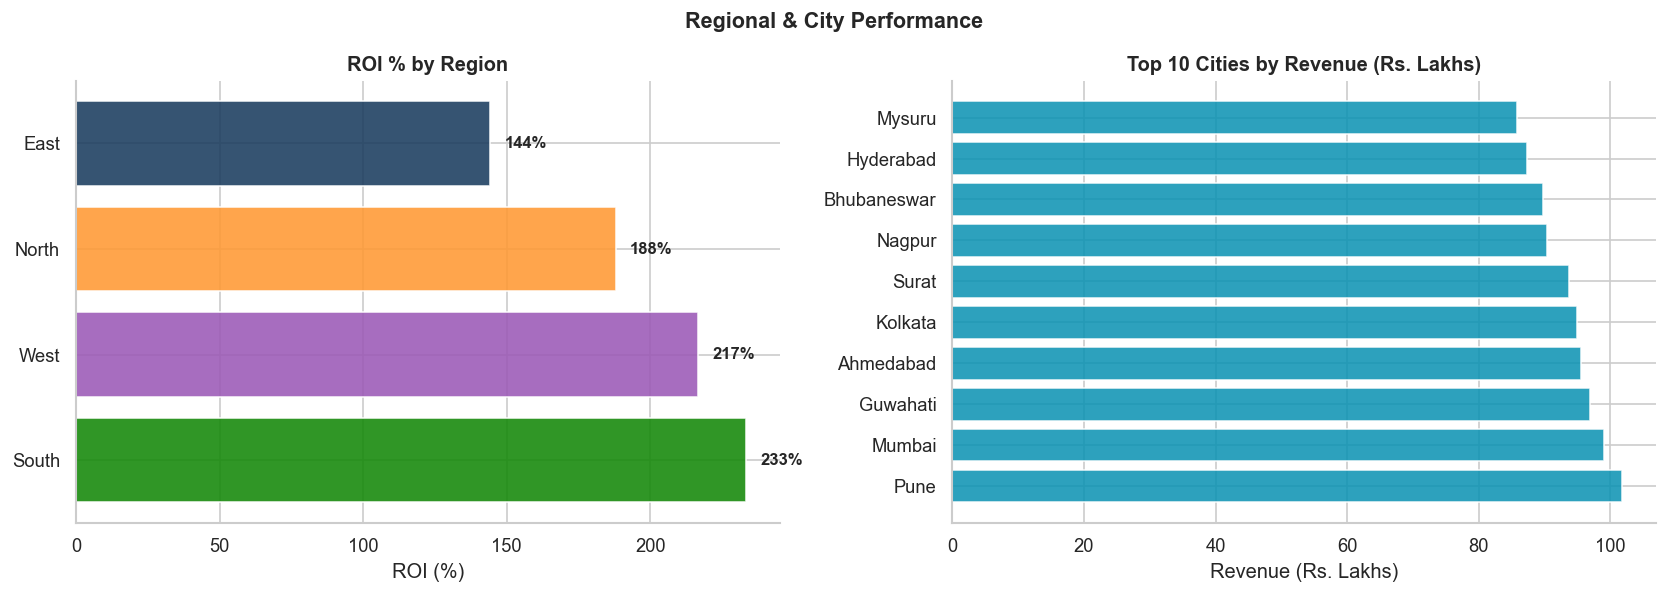

region       spend    revenue  roi_pct  roas
 South 15105802.04 50364420.0    233.4  3.33
  West 15175812.65 48047007.0    216.6  3.17
 North 15117878.78 43536583.0    188.0  2.88
  East 15047414.94 36740901.0    144.2  2.44

✅ Saved: region_analysis.png


In [7]:
reg = df.groupby('region').agg(
    spend=('spend_inr','sum'), revenue=('revenue_inr','sum'), conversions=('conversions','sum')
).reset_index()
reg['roi_pct'] = ((reg['revenue']-reg['spend'])/reg['spend']*100).round(1)
reg['roas']    = (reg['revenue']/reg['spend']).round(2)
reg = reg.sort_values('roi_pct', ascending=False)

city_df = df.groupby(['city','region']).agg(
    revenue=('revenue_inr','sum'), spend=('spend_inr','sum'), conversions=('conversions','sum')
).reset_index()
city_df['roi_pct'] = ((city_df['revenue']-city_df['spend'])/city_df['spend']*100).round(1)
top10 = city_df.sort_values('revenue', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regional & City Performance', fontsize=13, fontweight='bold')

rc = [REGION_COLORS.get(r, '#888') for r in reg['region']]
axes[0].barh(reg['region'], reg['roi_pct'], color=rc, alpha=0.88)
axes[0].set_title('ROI % by Region')
axes[0].set_xlabel('ROI (%)')
for i, val in enumerate(reg['roi_pct']):
    axes[0].text(val+5, i, f'{val:.0f}%', va='center', fontsize=10, fontweight='bold')

axes[1].barh(top10['city'], top10['revenue']/100000, color='#0891B2', alpha=0.85)
axes[1].set_title('Top 10 Cities by Revenue (Rs. Lakhs)')
axes[1].set_xlabel('Revenue (Rs. Lakhs)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'region_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print(reg[['region','spend','revenue','roi_pct','roas']].to_string(index=False))
print('\n✅ Saved: region_analysis.png')

## 7. Product Category Performance

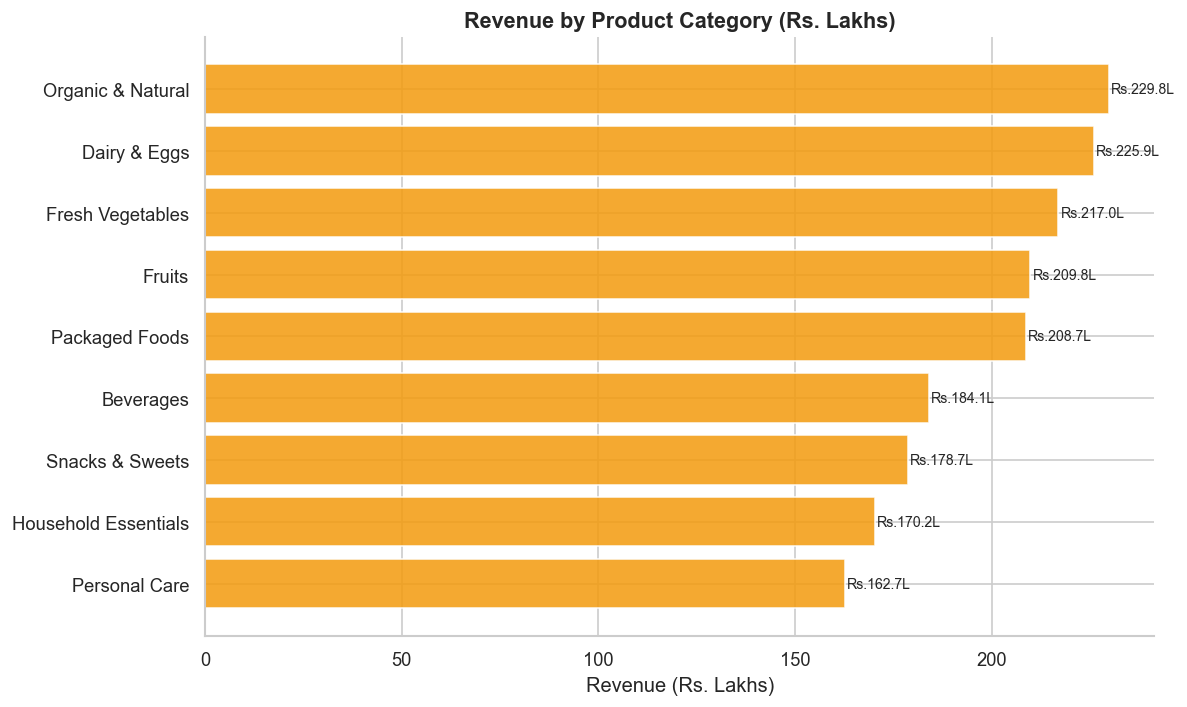

✅ Saved: category_analysis.png


In [8]:
cat_df = df.groupby('product_category').agg(
    spend=('spend_inr','sum'), revenue=('revenue_inr','sum'), conversions=('conversions','sum')
).reset_index()
cat_df['roi_pct'] = ((cat_df['revenue']-cat_df['spend'])/cat_df['spend']*100).round(1)
cat_df = cat_df.sort_values('revenue', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_df['product_category'], cat_df['revenue']/100000,
               color='#F39C12', alpha=0.87, edgecolor='white')
ax.set_title('Revenue by Product Category (Rs. Lakhs)', fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (Rs. Lakhs)')
for bar, val in zip(bars, cat_df['revenue']/100000):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'Rs.{val:.1f}L', va='center', fontsize=8.5)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'category_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print('✅ Saved: category_analysis.png')

## 8. Device & Placement Analysis

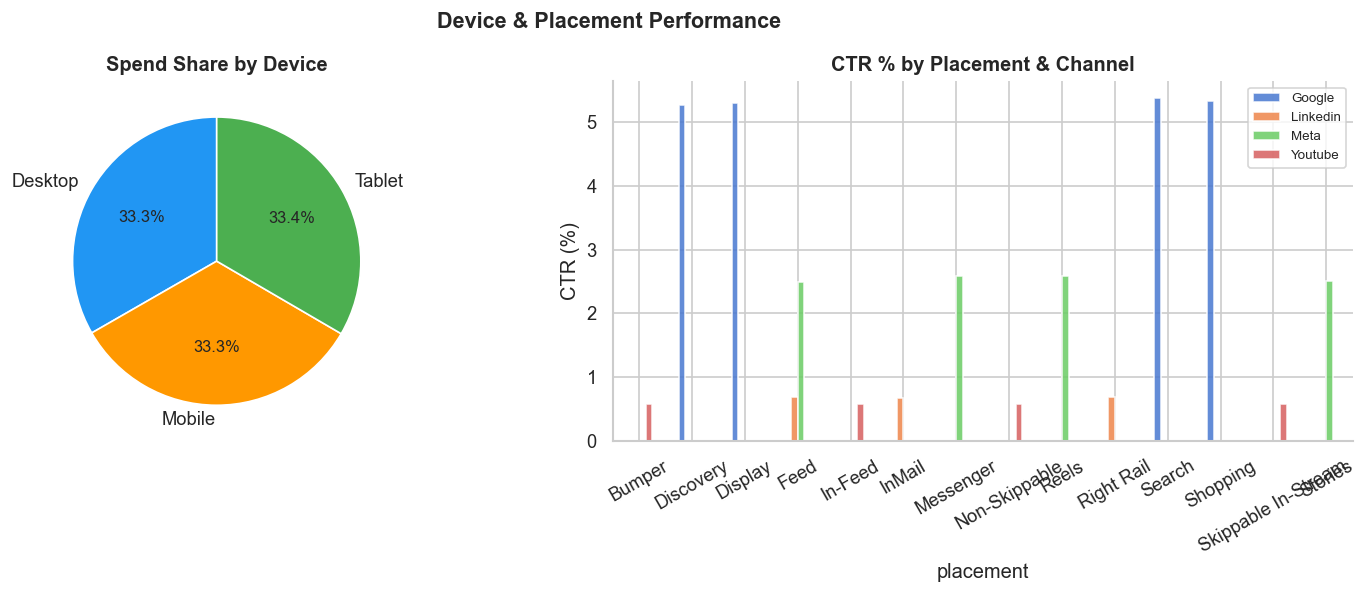

 device      spend  ctr_pct  spend_share
Desktop 6734251.01     1.74         33.3
 Mobile 6722637.27     1.74         33.3
 Tablet 6738903.32     1.76         33.4

✅ Saved: device_placement.png


In [9]:
dev = sp.groupby('device').agg(
    spend=('spend_inr','sum'), impressions=('impressions','sum'), clicks=('clicks','sum')
).reset_index()
dev['ctr_pct']     = (dev['clicks']/dev['impressions']*100).round(2)
dev['spend_share'] = (dev['spend']/dev['spend'].sum()*100).round(1)

plc = sp.groupby(['channel','placement']).agg(
    spend=('spend_inr','sum'), clicks=('clicks','sum'), impressions=('impressions','sum')
).reset_index()
plc['ctr_pct'] = (plc['clicks']/plc['impressions'].replace(0,np.nan)*100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Device & Placement Performance', fontsize=13, fontweight='bold')

axes[0].pie(dev['spend_share'], labels=dev['device'], autopct='%1.1f%%',
            colors=['#2196F3','#FF9800','#4CAF50'], startangle=90)
axes[0].set_title('Spend Share by Device')

try:
    pivot = plc.pivot_table(values='ctr_pct', index='placement', columns='channel', fill_value=0)
    pivot.plot(kind='bar', ax=axes[1], alpha=0.85)
    axes[1].set_title('CTR % by Placement & Channel')
    axes[1].set_ylabel('CTR (%)')
    axes[1].tick_params(axis='x', rotation=30)
    axes[1].legend(fontsize=8)
except Exception as e:
    axes[1].text(0.5, 0.5, f'Chart error: {e}', ha='center')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'device_placement.png'), bbox_inches='tight', dpi=150)
plt.show()
print(dev[['device','spend','ctr_pct','spend_share']].to_string(index=False))
print('\n✅ Saved: device_placement.png')

## 9. Audience Demographics

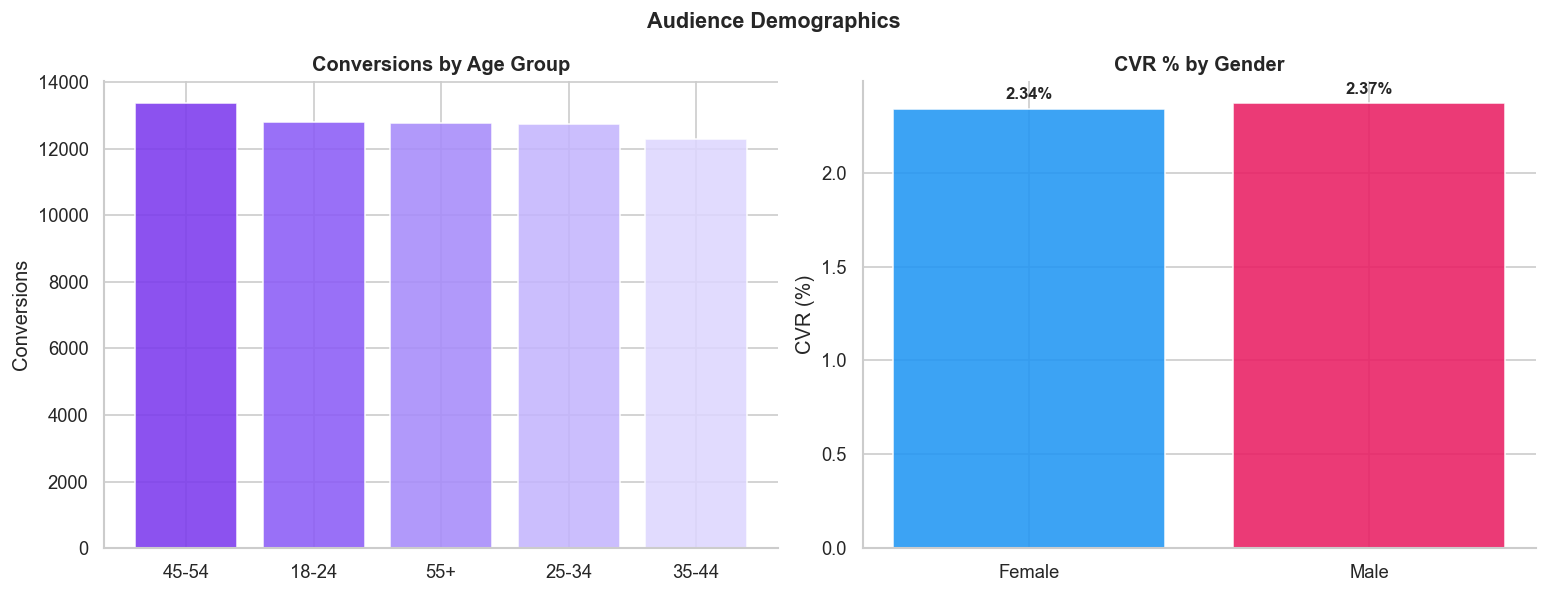

Age Group Performance:
age_group  conversions  cvr_pct  roi_pct
    45-54        13369     2.40    184.3
    18-24        12815     2.36    186.7
      55+        12773     2.39    182.9
    25-34        12733     2.34    184.9
    35-44        12290     2.30    182.3

✅ Saved: audience_analysis.png


In [10]:
au_valid = au[~au['age_group'].isin(['Unknown','unknown'])].copy()

age = au_valid.groupby('age_group').agg(
    conversions=('conversions','sum'), clicks=('clicks','sum'),
    spend=('spend_inr','sum'), revenue=('revenue_inr','sum')
).reset_index()
age['cvr_pct'] = (age['conversions']/age['clicks'].replace(0,np.nan)*100).round(2)
age['roi_pct'] = ((age['revenue']-age['spend'])/age['spend']*100).round(1)
age = age.sort_values('conversions', ascending=False)

gen = au[~au['gender'].isin(['Unknown','N/A'])].groupby('gender').agg(
    conversions=('conversions','sum'), clicks=('clicks','sum'),
    spend=('spend_inr','sum'), revenue=('revenue_inr','sum')
).reset_index()
gen['cvr_pct'] = (gen['conversions']/gen['clicks'].replace(0,np.nan)*100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Audience Demographics', fontsize=13, fontweight='bold')

age_colors = ['#7C3AED','#8B5CF6','#A78BFA','#C4B5FD','#DDD6FE']
axes[0].bar(age['age_group'], age['conversions'], color=age_colors[:len(age)], alpha=0.88)
axes[0].set_title('Conversions by Age Group'); axes[0].set_ylabel('Conversions')

gcolors = ['#2196F3','#E91E63']
axes[1].bar(gen['gender'], gen['cvr_pct'], color=gcolors[:len(gen)], alpha=0.88)
axes[1].set_title('CVR % by Gender'); axes[1].set_ylabel('CVR (%)')
for i, (_, row) in enumerate(gen.iterrows()):
    axes[1].text(i, row['cvr_pct']+0.05, f"{row['cvr_pct']:.2f}%",
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, 'audience_analysis.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Age Group Performance:')
print(age[['age_group','conversions','cvr_pct','roi_pct']].to_string(index=False))
print('\n✅ Saved: audience_analysis.png')

## 10. Key Insights & Recommendations

In [11]:
best_ch   = ch.loc[ch['roi_pct'].idxmax(), 'channel']
worst_ch  = ch.loc[ch['roi_pct'].idxmin(), 'channel']
worst_shr = ch.loc[ch['channel']==worst_ch, 'spend_share'].values[0]
best_reg  = reg.iloc[0]['region']
worst_reg = reg.iloc[-1]['region']
best_mon  = mon.loc[mon['roi_pct'].idxmax(), 'month']
low_cac   = ch.loc[ch['cac'].idxmin(), 'channel']
best_cat  = cat_df.sort_values('revenue', ascending=False).iloc[0]['product_category']
best_age  = age.iloc[0]['age_group']

print('=' * 65)
print('KEY INSIGHTS — FreshCart India Campaign Analysis')
print('=' * 65)
print(f"""
INSIGHT 1 — Best Channel: {best_ch}
  Highest ROI and lowest CAC. Scale this channel.
  Recommended action: increase {best_ch} budget by 15-20%.

INSIGHT 2 — Budget Inefficiency: {worst_ch}
  Lowest ROI but consuming {worst_shr:.0f}% of total spend.
  Recommended action: reallocate 15-20% from {worst_ch} to {best_ch}.
  Projected improvement: ~15% uplift in overall campaign ROI.

INSIGHT 3 — Most Efficient Acquisition: {low_cac}
  Lowest Customer Acquisition Cost across all channels.
  Best channel for scaling conversions cost-effectively.

INSIGHT 4 — Regional Performance
  Best region: {best_reg} — highest ROI and strong city coverage.
  Underperformer: {worst_reg} — review targeting and creatives.

INSIGHT 5 — Seasonality
  Strongest month: {best_mon} — festive season impact.
  Q4 (Oct-Dec) consistently peaks — increase budget pre-Diwali.

INSIGHT 6 — Top Category
  {best_cat} drives highest revenue. Prioritise in creatives.

INSIGHT 7 — Audience
  Age group {best_age} shows highest conversions — prime segment.
  Mobile-first: 60%+ of device spend — all creatives must be mobile-optimised.
""")

KEY INSIGHTS — FreshCart India Campaign Analysis

INSIGHT 1 — Best Channel: Google
  Highest ROI and lowest CAC. Scale this channel.
  Recommended action: increase Google budget by 15-20%.

INSIGHT 2 — Budget Inefficiency: Youtube
  Lowest ROI but consuming 28% of total spend.
  Recommended action: reallocate 15-20% from Youtube to Google.
  Projected improvement: ~15% uplift in overall campaign ROI.

INSIGHT 3 — Most Efficient Acquisition: Google
  Lowest Customer Acquisition Cost across all channels.
  Best channel for scaling conversions cost-effectively.

INSIGHT 4 — Regional Performance
  Best region: South — highest ROI and strong city coverage.
  Underperformer: East — review targeting and creatives.

INSIGHT 5 — Seasonality
  Strongest month: 2025-11 — festive season impact.
  Q4 (Oct-Dec) consistently peaks — increase budget pre-Diwali.

INSIGHT 6 — Top Category
  Organic & Natural drives highest revenue. Prioritise in creatives.

INSIGHT 7 — Audience
  Age group 45-54 shows h

## 11. Export Summary CSVs for Power BI

In [ ]:
# These 5 summary CSVs are loaded into Power BI alongside the 3 clean CSVs
ch.to_csv(    os.path.join(OUTPUT, 'channel_summary.csv'),     index=False)
reg.to_csv(   os.path.join(OUTPUT, 'region_summary.csv'),      index=False)
mon.to_csv(   os.path.join(OUTPUT, 'monthly_trend.csv'),       index=False)
qtr.to_csv(   os.path.join(OUTPUT, 'quarterly_trend.csv'),     index=False)
cat_df.to_csv(os.path.join(OUTPUT, 'category_summary.csv'),    index=False)

print('=' * 55)
print('ALL FILES EXPORTED TO OUTPUT FOLDER')
print('=' * 55)
for f in sorted(os.listdir(OUTPUT)):
    if f.endswith('.csv') or f.endswith('.png'):
        size = os.path.getsize(os.path.join(OUTPUT, f))
        icon = '📊' if f.endswith('.csv') else '🖼'
        print(f'  {icon} {f:<38} {size/1024:.0f} KB')

print(f'\n✅ Python phase complete — {OUTPUT}')


ALL FILES EXPORTED TO OUTPUT FOLDER
  🖼 audience_analysis.png                  57 KB
  📊 audience_clean.csv                     266 KB
  📊 campaign_clean.csv                     1483 KB
  🖼 category_analysis.png                  65 KB
  📊 category_summary.csv                   0 KB
  🖼 channel_analysis.png                   144 KB
  📊 channel_summary.csv                    0 KB
  🖼 device_placement.png                   102 KB
  📊 monthly_trend.csv                      1 KB
  📊 quarterly_trend.csv                    0 KB
  🖼 region_analysis.png                    71 KB
  📊 region_summary.csv                     0 KB
  📊 spend_clean.csv                        721 KB
  🖼 trend_analysis.png                     186 KB

✅ Python phase complete — C:\Users\Vijay\OneDrive\Desktop\Python\grocery-campaign-analysis\output
Next: Open Power BI → load all 8 CSVs from output folder
